In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\246506\Downloads\spam.csv', encoding='latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3294,ham,Dunno lei Ì_ all decide lor. How abt leona? Oo...,NaN,NaN,NaN
3570,ham,But you dint in touch with me.,NaN,NaN,NaN
238,ham,"New Theory: Argument wins d SITUATION, but los...",NaN,NaN,NaN
5190,spam,Our records indicate u maybe entitled to 5000 ...,NaN,NaN,NaN
4226,ham,Buy one egg for me da..please:),NaN,NaN,NaN
101,ham,I'm still looking for a car to buy. And have n...,NaN,NaN,NaN
4838,ham,That's one of the issues but california is oka...,NaN,NaN,NaN
4528,ham,"Hiya, probably coming home * weekend after next",NaN,NaN,NaN
1672,spam,URGENT! We are trying to contact U. Todays dra...,NaN,NaN,NaN
3103,ham,That's y i said it's bad dat all e gals know u...,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# cloumn 2,3,4 are useless
df=df.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
label_encoder = LabelEncoder()
df['v1']=label_encoder.fit_transform(df['v1'])

In [9]:
df.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df = df.rename(columns = {'v1':'output','v2':'text'})

In [11]:
df.isnull().sum()

output    0
text      0
dtype: int64

In [12]:
df.duplicated().sum()

403

In [13]:
df=df.drop_duplicates(keep='first')

In [14]:
df.shape

(5169, 2)

In [15]:
#EDA
df['output'].value_counts()

output
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x1ef7184fa10>,
 [Text(-1.0144997251399075, 0.4251944351600247, 'ham'),
  Text(1.014499764949479, -0.4251943401757036, 'spam')],
 [Text(-0.5533634864399495, 0.23192423736001344, '87.37'),
  Text(0.5533635081542612, -0.23192418555038377, '12.63')])

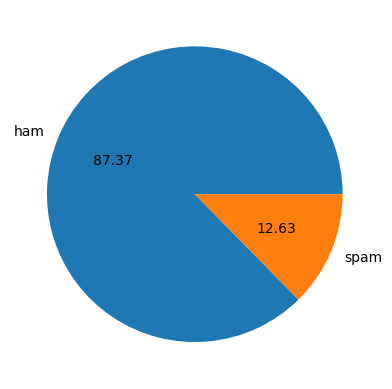

In [16]:
plt.pie(df['output'].value_counts(), labels=['ham','spam'],autopct="%0.2f")

In [17]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [18]:
import nltk

In [19]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\246506\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
df['no_of_chars']=df['text'].apply(len)

In [21]:
df.head()

,output,text,no_of_chars
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [22]:
df['text'].apply(lambda x:nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [23]:
df['no_of_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [24]:
df.head()

,output,text,no_of_chars,no_of_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
df['text'].apply(lambda x:nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: text, Length: 5169, dtype: object

In [26]:
df['no_of_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [27]:
df.head()

,output,text,no_of_chars,no_of_words,no_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
df[['no_of_chars','no_of_words','no_of_sentences']].describe()

,no_of_chars,no_of_words,no_of_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
df[df['output']==0][['no_of_chars','no_of_words','no_of_sentences']].describe() #ham

,no_of_chars,no_of_words,no_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
df[df['output']==1][['no_of_chars','no_of_words','no_of_sentences']].describe() #spam

,no_of_chars,no_of_words,no_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


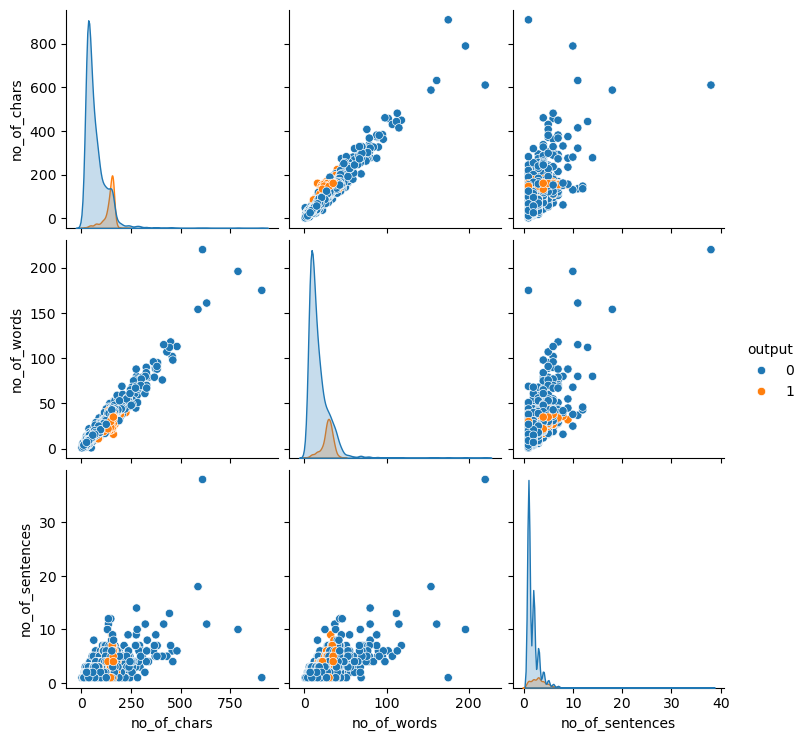

In [31]:
sns.pairplot(df,hue='output')

<Axes: xlabel='no_of_chars', ylabel='Count'>

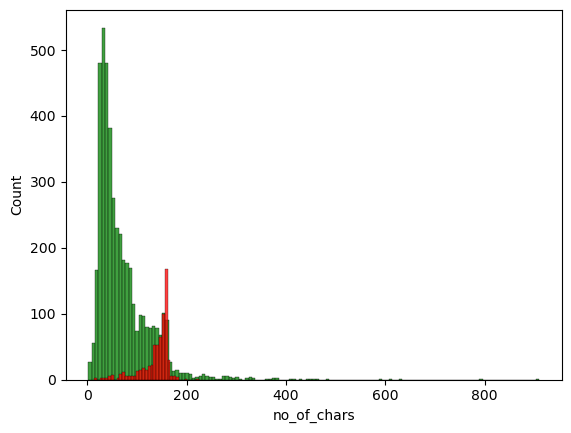

In [32]:
sns.histplot(df[df['output']==0]['no_of_chars'],color='green')
sns.histplot(df[df['output']==1]['no_of_chars'],color='red')

<Axes: xlabel='no_of_words', ylabel='Count'>

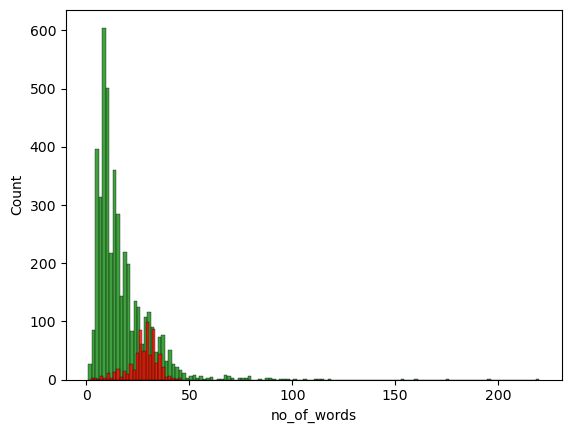

In [33]:
sns.histplot(df[df['output']==0]['no_of_words'],color='green')
sns.histplot(df[df['output']==1]['no_of_words'],color='red')

<Axes: xlabel='no_of_sentences', ylabel='Count'>

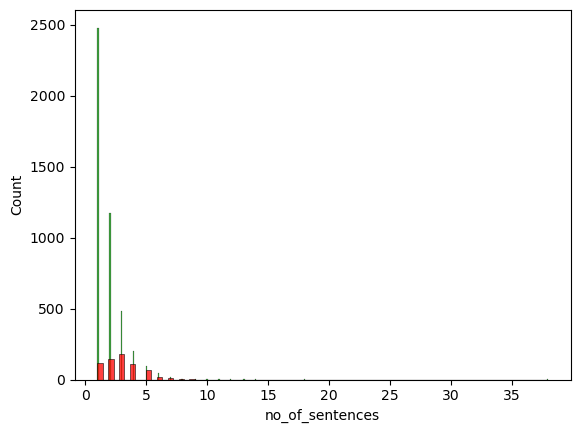

In [34]:
sns.histplot(df[df['output']==0]['no_of_sentences'],color='green')
sns.histplot(df[df['output']==1]['no_of_sentences'],color='red')

In [35]:
df_num = df.select_dtypes(include='number')
corr_matrix=df_num.corr()
corr_matrix

,output,no_of_chars,no_of_words,no_of_sentences
output,1.000000,0.384717,0.262912,0.263939
no_of_chars,0.384717,1.000000,0.965760,0.624139
no_of_words,0.262912,0.965760,1.000000,0.679971
no_of_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

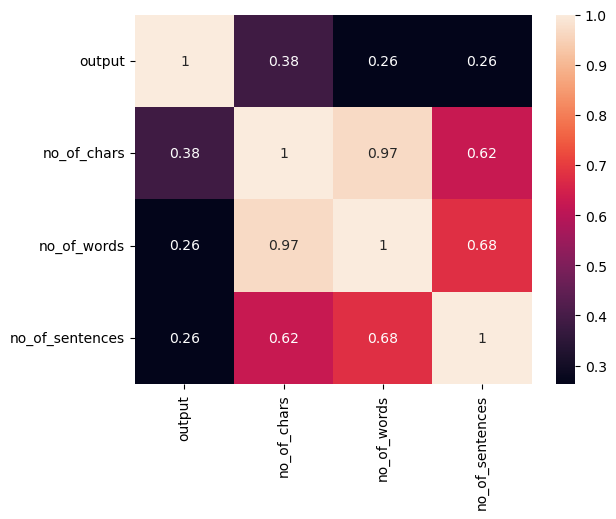

In [36]:
sns.heatmap(corr_matrix,annot=True)

In [37]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\246506\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [38]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [39]:
from nltk.stem.porter import PorterStemmer
por_stem = PorterStemmer()

In [40]:
#Data Preprocessing
def text_processor(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    p=[]
    for i in text:
        if i.isalnum():
            p.append(i)
    text=p[:];
    p.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            p.append(i)

    text=p[:]
    p.clear()
    for i in text:
        p.append(por_stem.stem(i))
    return " ".join(p)
    

In [41]:
text_processor('you son of a **** .Are you Gay? Why are you dancing like a peacock in this raining doomsday?')

'son gay danc like peacock rain doomsday'

In [42]:
text_processor(df['text'][0])

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [43]:
df['processed_text'] = df['text'].apply(text_processor)

In [44]:
df.head()

,output,text,no_of_chars,no_of_words,no_of_sentences,processed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [45]:
pip install WordCloud

Note: you may need to restart the kernel to use updated packages.


In [46]:
from wordcloud import WordCloud
wc = WordCloud(width=1000 , height =1000 , min_font_size=10,background_color='white')

In [47]:
spamwc = wc.generate(df[df['output']==1]['processed_text'].str.cat(sep=" "))

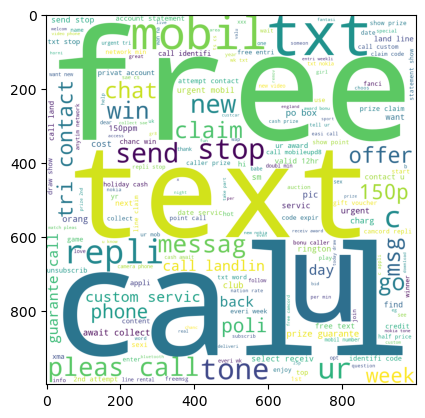

In [48]:
plt.imshow(spamwc)

In [49]:
hamwc = wc.generate(df[df['output']==0]['processed_text'].str.cat(sep=" "))

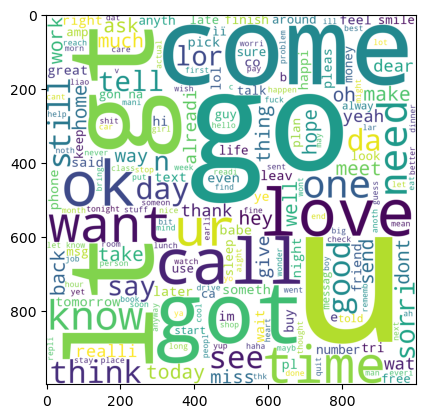

In [50]:
plt.imshow(hamwc)

In [51]:
spam_corpus=[]
for sent in df[df['output']==1]['processed_text'].tolist():
    for word in sent.split():
        spam_corpus.append(word)

In [52]:
len(spam_corpus)

9939

In [53]:
from collections import Counter

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'call'),
  Text(1, 0, 'free'),
  Text(2, 0, '2'),
  Text(3, 0, 'txt'),
  Text(4, 0, 'text'),
  Text(5, 0, 'u'),
  Text(6, 0, 'ur'),
  Text(7, 0, 'mobil'),
  Text(8, 0, 'stop'),
  Text(9, 0, 'repli'),
  Text(10, 0, 'claim'),
  Text(11, 0, '4'),
  Text(12, 0, 'prize'),
  Text(13, 0, 'get'),
  Text(14, 0, 'new'),
  Text(15, 0, 'servic'),
  Text(16, 0, 'tone'),
  Text(17, 0, 'send'),
  Text(18, 0, 'urgent'),
  Text(19, 0, 'nokia'),
  Text(20, 0, 'contact'),
  Text(21, 0, 'award'),
  Text(22, 0, 'phone'),
  Text(23, 0, 'cash'),
  Text(24, 0, 'pleas'),
  Text(25, 0, 'week'),
  Text(26, 0, 'win'),
  Text(27, 0, 'c'),
  Text(28, 0, 'collect'),
  Text(29, 0, 'min')])

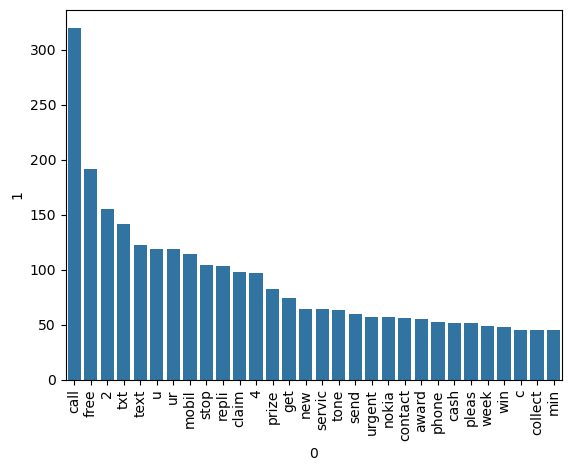

In [54]:
sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')

In [55]:
ham_corpus=[]
for sent in df[df['output']==0]['processed_text'].tolist():
    for word in sent.split():
        ham_corpus.append(word)

len(ham_corpus)

35404

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'u'),
  Text(1, 0, 'go'),
  Text(2, 0, 'get'),
  Text(3, 0, 'gt'),
  Text(4, 0, 'lt'),
  Text(5, 0, '2'),
  Text(6, 0, 'come'),
  Text(7, 0, 'got'),
  Text(8, 0, 'know'),
  Text(9, 0, 'like'),
  Text(10, 0, 'call'),
  Text(11, 0, 'time'),
  Text(12, 0, 'ok'),
  Text(13, 0, 'love'),
  Text(14, 0, 'good'),
  Text(15, 0, 'want'),
  Text(16, 0, 'ur'),
  Text(17, 0, 'day'),
  Text(18, 0, 'need'),
  Text(19, 0, 'one'),
  Text(20, 0, 'lor'),
  Text(21, 0, '4'),
  Text(22, 0, 'home'),
  Text(23, 0, 'think'),
  Text(24, 0, 'see'),
  Text(25, 0, 'take'),
  Text(26, 0, 'still'),
  Text(27, 0, 'da'),
  Text(28, 0, 'tell'),
  Text(29, 0, 'make')])

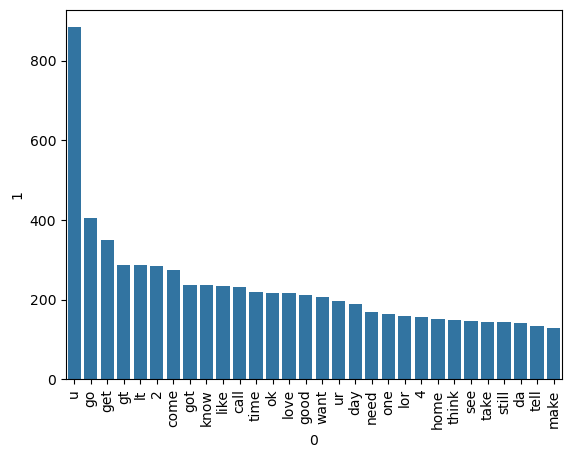

In [56]:
sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')

In [57]:
#Model Building
from sklearn.feature_extraction.text import CountVectorizer ,TfidfVectorizer
cv = CountVectorizer()
tfidv = TfidfVectorizer()
X = tfidv.fit_transform(df['processed_text']).toarray()

In [58]:
X.shape

(5169, 6708)

In [59]:
y=df['output'].values

In [60]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [61]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=42) 

In [62]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB,BernoulliNB

In [63]:
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score

In [64]:
mnb=MultinomialNB()
gnb=GaussianNB()
bnb=BernoulliNB()

In [65]:
mnb.fit(X_train,y_train)
y_pred1=mnb.predict(X_test)
print("Accuracy Score:",accuracy_score(y_test,y_pred1))
print("Confusion Matrix",confusion_matrix(y_test,y_pred1))
print("Precision Score",precision_score(y_test,y_pred1))

Accuracy Score: 0.9542230818826564
Confusion Matrix [[1331    0]
 [  71  149]]
Precision Score 1.0


In [66]:
gnb.fit(X_train,y_train)
y_pred2=gnb.predict(X_test)
print("Accuracy Score:",accuracy_score(y_test,y_pred2))
print("Confusion Matrix",confusion_matrix(y_test,y_pred2))
print("Precision Score",precision_score(y_test,y_pred2))

Accuracy Score: 0.8749194068343005
Confusion Matrix [[1171  160]
 [  34  186]]
Precision Score 0.5375722543352601


In [67]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print("Accuracy Score:",accuracy_score(y_test,y_pred3))
print("Confusion Matrix",confusion_matrix(y_test,y_pred3))
print("Precision Score",precision_score(y_test,y_pred3))

Accuracy Score: 0.9658284977433914
Confusion Matrix [[1326    5]
 [  48  172]]
Precision Score 0.9717514124293786


In [68]:
#trfidf->MNB

In [69]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [71]:
svc = SVC(kernel='sigmoid',gamma=1.0,probability=True)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=42)
abc = AdaBoostClassifier(n_estimators=50, random_state=42)
bc = BaggingClassifier(n_estimators=50, random_state=42)
etc = ExtraTreesClassifier(n_estimators=50, random_state=42)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=42)
xgb = XGBClassifier(n_estimators=50,random_state=42)

In [72]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [73]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy =accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [74]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9722759509993553, 0.9682539682539683)

In [75]:
accuracy_scores = []
precision_scores = []
for name,clf in clfs.items():
    curr_accuracy,curr_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    accuracy_scores.append(curr_accuracy)
    precision_scores.append(curr_precision)

C:\Users\246506\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [76]:
clfs_performance= pd.DataFrame({'Algorithm':clfs.keys(), 'Accuracy Score':accuracy_scores, 'Precision Score':precision_scores}).sort_values('Precision Score',ascending=False)

In [77]:
clfs_performance

,Algorithm,Accuracy Score,Precision Score
1,KN,0.888459,1.000000
2,NB,0.954223,1.000000
5,RF,0.965184,0.994048
8,ETC,0.974210,0.989130
0,SVC,0.972276,0.968254
10,xgb,0.970342,0.957895
9,GBDT,0.947776,0.926380
6,AdaBoost,0.955513,0.908108
7,BgC,0.963894,0.901961
4,LR,0.941973,0.886905


In [78]:
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators = [('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [79]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=42))],
                 voting='soft')

In [80]:
y_pred=voting.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred))     

Accuracy: 0.9825918762088974
Precision: 1.0


In [81]:
from sklearn.ensemble import StackingClassifier

In [82]:
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [83]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9832366215344939
Precision 0.9663461538461539


In [170]:
import pickle
pickle.dump(voting,open('model.pkl','wb'))
pickle.dump(tfidv,open('vectorizer.pkl','wb'))